# Phase 5 — SHAP Explainability + Retention Levers

**Goal:** turn the churn model from a black box into a decision-support tool. For each
flagged subscriber, we explain **why** the model flagged them AND **which retention
lever** the PM should pull.

**Two audiences:**
- **Data science** — proper SHAP methodology (TreeExplainer, log-odds space, global vs
  local, ranked importance)
- **Product** — feature → intervention mapping curated with the PM, three worked
  examples showing *"flag + why + what to do"*

## Sections

| Section | Purpose |
|---|---|
| **A. Setup** | Load features, retrain uncalibrated XGB (SHAP needs the raw booster) |
| **B. Compute SHAP** | TreeExplainer on a 2K test sample |
| **C. Global importance** | Mean-abs-SHAP ranked feature table + bar chart |
| **D. Beeswarm** | Direction + magnitude across the sample |
| **E. Dependence** | How SHAP shifts with feature value for the top 3 drivers |
| **F. Local explanations** | Three worked examples: HIGH / MARGINAL / LOW risk |
| **G. Intervention map** | Feature → lever + cost lookup table |
| **H. Verdict** | Handoff to Phase 6 decision rule |

All figures saved under `reports/figures/`.

In [1]:
import os
import sys
import warnings
from pathlib import Path

# Silence a sklearn 1.8+ FutureWarning triggered inside SHAP / other deps
# (they call the deprecated `sklearn.utils.extmath.stable_cumsum`). Will
# clear itself once those libraries release a compatible version. Not our
# code, not actionable here.
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message="Function stable_cumsum is deprecated",
)

# Run from project root whether invoked as `python notebooks/05_...` or
# from a Jupyter cell (which doesn't define __file__).
try:
    _project_root = Path(__file__).resolve().parents[1]
except NameError:
    _here = Path.cwd()
    _project_root = _here.parent if _here.name == "notebooks" else _here
os.chdir(_project_root)
sys.path.insert(0, str(_project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split

from src.data.loader import load_subscribers
from src.features.transforms import build_features
from src.models.train import prepare_features, train_hist_gbm, tune_hist_gbm_optuna
from src.models.evaluate import compute_metrics
from src.models.explain import (
    compute_shap_values, global_importance, local_explanation,
    map_to_intervention, FEATURE_INTERVENTION_MAP,
)
from src.decisions.policy import INTERVENTION_MENU, LTV_BY_TIER

FIG_DIR = Path("reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

c:\Users\ruthr\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## A. Setup — retrain uncalibrated HistGBM for SHAP

The calibrated model runs in production for probabilities; this uncalibrated version
is what runs SHAP because TreeExplainer needs direct access to the tree
structure (the calibration wrapper hides it). Same three-way split as Phase 4 (same
seed) so we're explaining the same model on the same test users.

**Note:** After the v1.1 flip to HistGBM production, this notebook retrains
HistGradientBoosting (not XGBoost) so SHAP explains the SAME model that ships.
SHAP's TreeExplainer supports HistGBM since SHAP 0.35+.

In [2]:
print("=" * 70)
print("A. SETUP -- load model + test features")
print("=" * 70)

raw = load_subscribers("data/subscribers.csv")
df = build_features(raw)
X, y = prepare_features(df)

# Same three-way split as Phase 4 (same seed) so we're explaining the
# same model on the same test users.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42,
)
X_train, X_calib, y_train, y_calib = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42,
)

# Retrain uncalibrated HistGBM -- SHAP needs direct access to the tree
# structure. The calibrated model is what runs in production for
# probabilities; this one is what runs SHAP.
#
# Match Phase 4's variant selection: train both default and Optuna-tuned,
# pick whichever wins on TEST PR-AUC. This way SHAP explains the SAME
# variant that ships, not just the default.
hgb_default = train_hist_gbm(X_train, y_train)
hgb_tuned, _best_params = tune_hist_gbm_optuna(
    X_train, y_train, X_calib, y_calib, n_trials=25, random_state=42,
)
default_pr = compute_metrics(
    y_test, hgb_default.predict_proba(X_test)[:, 1])["pr_auc"]
tuned_pr = compute_metrics(
    y_test, hgb_tuned.predict_proba(X_test)[:, 1])["pr_auc"]
hgb = hgb_tuned if tuned_pr > default_pr else hgb_default
variant = "tuned" if tuned_pr > default_pr else "default"
print(f"Retrained HistGBM ({variant}) on train (n={len(X_train):,}) for SHAP")
print(f"  default test PR-AUC: {default_pr:.4f}")
print(f"  tuned   test PR-AUC: {tuned_pr:.4f}  -->  using {variant}")

A. SETUP -- load model + test features
Retrained HistGBM (tuned) on train (n=30,000) for SHAP
  default test PR-AUC: 0.1708
  tuned   test PR-AUC: 0.1779  -->  using tuned


## B. Compute SHAP values (TreeExplainer)

Sample 2,000 test users — SHAP over the full test set is unnecessary and slow. Global
patterns show up cleanly at n=2000. Sanity-check that
`sum(SHAP) + base_value == raw model margin`.

In [3]:
print("\n" + "=" * 70)
print("B. COMPUTE SHAP VALUES (TreeExplainer)")
print("=" * 70)
SAMPLE_SIZE = 2000
shap_values = compute_shap_values(hgb, X_test, sample_size=SAMPLE_SIZE)
X_shap = X_test.sample(n=SAMPLE_SIZE, random_state=42)
y_shap = y_test.loc[X_shap.index]
print(f"Computed SHAP for {SAMPLE_SIZE} test users")
print(f"Base value (expected log-odds output): {shap_values.base_values[0]:.4f}")
print(f"Base value (as probability): {1/(1+np.exp(-shap_values.base_values[0])):.4f}")
# Sanity check: sum(SHAP) + base_value == raw model output
# HistGBM's decision_function returns log-odds directly (equivalent to
# XGBoost's `output_margin=True`) — use that for the additivity check.
sample_pred = hgb.decision_function(X_shap.iloc[[0]])[0]
sample_check = shap_values.values[0].sum() + shap_values.base_values[0]
print(f"Sanity check (should match): raw margin={sample_pred:.4f}, "
      f"sum(shap)+base={sample_check:.4f}")


B. COMPUTE SHAP VALUES (TreeExplainer)
Computed SHAP for 2000 test users
Base value (expected log-odds output): -3.1946
Base value (as probability): 0.0394
Sanity check (should match): raw margin=-3.9140, sum(shap)+base=-3.9140


## C. Global feature importance — mean |SHAP|

Ranked feature contribution to the model's log-odds output — **magnitude only**.
This chart answers "which features matter most?", not "does a high value push
toward or away from churn?". For direction, see the beeswarm (Section D) or
the dependence plots (Section E).

**Why no color-by-direction here?** A signed-mean coloring mixes two things
— the feature's magnitude and the sample's value distribution — and can flip
the color for a feature whose HIGH values actually push AWAY from churn but
whose LOW values (dominating a skewed sample) push toward churn. That's
misleading. Keeping this chart to magnitude only, and reading direction off
the beeswarm, avoids the trap.


C. GLOBAL FEATURE IMPORTANCE (mean |SHAP|)
               feature  mean_abs_shap  mean_signed_shap
   watch_hours_last_7d       0.290218          0.002290
  billing_cycle_annual       0.253182         -0.007964
       logins_last_30d       0.169062         -0.010083
 days_since_last_login       0.152581          0.005104
  payment_health_score       0.147511          0.002482
 watch_trend_7d_to_30d       0.119879         -0.000669
         tenure_months       0.114879          0.000839
watch_trend_30d_to_90d       0.064543         -0.001558
tenure_bucket_m2_trial       0.060977          0.001608
         multi_profile       0.057786         -0.000478
     plan_tier_Premium       0.056545         -0.001051
  watch_hours_last_90d       0.026666          0.000157
            auto_renew       0.019959         -0.000305
    distinct_titles_7d       0.019613          0.000124
       plan_tier_Basic       0.019517          0.000108

Saved -> reports\figures/05_shap_global_importance.png


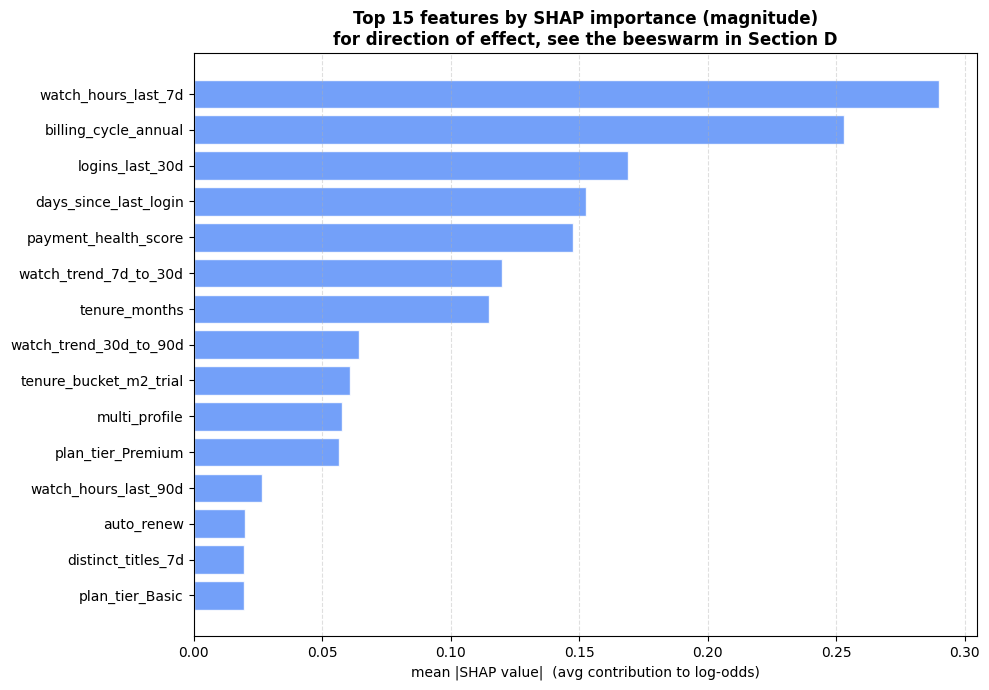

In [4]:
print("\n" + "=" * 70)
print("C. GLOBAL FEATURE IMPORTANCE (mean |SHAP|)")
print("=" * 70)
importance = global_importance(shap_values, list(X_shap.columns), top_n=15)
print(importance.to_string(index=False))

# Bar chart -- single color, magnitude only. Direction lives in the beeswarm.
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(importance["feature"][::-1], importance["mean_abs_shap"][::-1],
        color="#5B8FF9", alpha=0.85, edgecolor="white")
ax.set_xlabel("mean |SHAP value|  (avg contribution to log-odds)")
ax.set_title("Top 15 features by SHAP importance (magnitude)\n"
             "for direction of effect, see the beeswarm in Section D",
             fontweight="bold")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_shap_global_importance.png",
            dpi=140, bbox_inches="tight")
print(f"\nSaved -> {FIG_DIR}/05_shap_global_importance.png")
plt.show()

## D. SHAP summary plot (beeswarm)

One row per feature, one dot per user. X-position = SHAP contribution, color = feature
value (red high, blue low). Shows **both magnitude and direction** of effect across
the sample in one image.


D. SHAP SUMMARY PLOT (beeswarm)
Saved -> reports\figures/05_shap_beeswarm.png


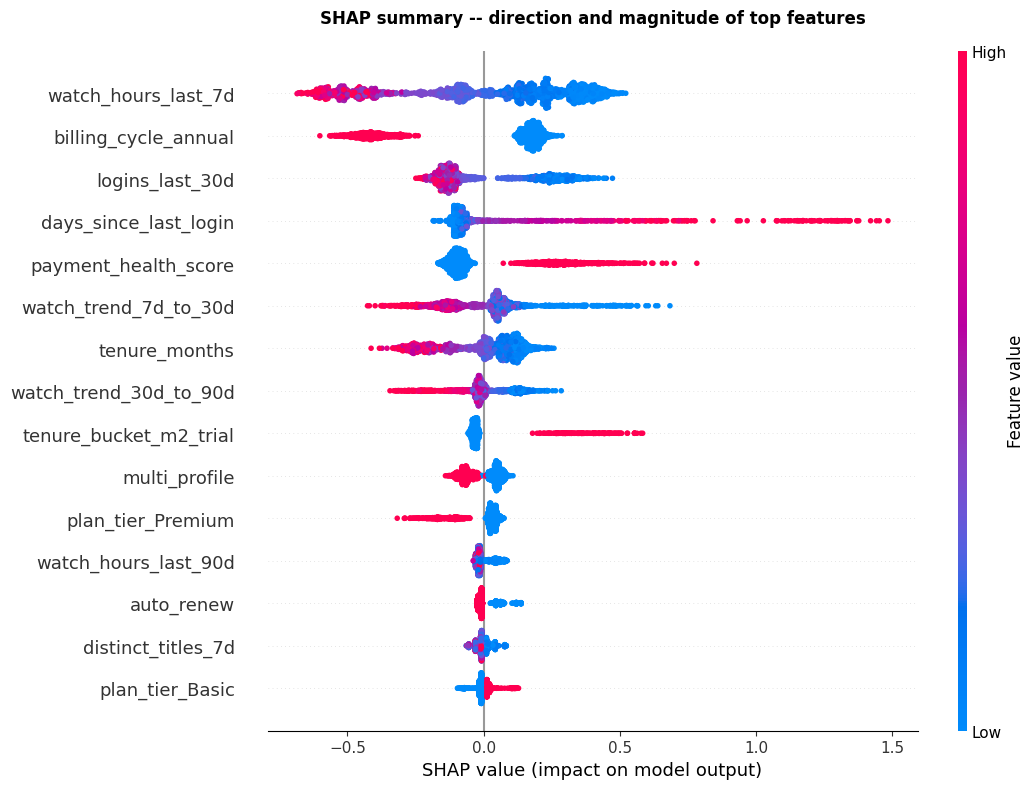

In [5]:
print("\n" + "=" * 70)
print("D. SHAP SUMMARY PLOT (beeswarm)")
print("=" * 70)
plt.figure(figsize=(11, 8))
shap.summary_plot(shap_values, X_shap, max_display=15, show=False,
                  plot_size=None)
plt.title("SHAP summary -- direction and magnitude of top features",
          fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_shap_beeswarm.png", dpi=140, bbox_inches="tight")
print(f"Saved -> {FIG_DIR}/05_shap_beeswarm.png")
plt.show()

## E. Feature dependence for top 3 drivers

Scatter of feature value (x) vs SHAP contribution (y) for the three most important
features. Reveals thresholds and non-linearities the tree learned.


E. FEATURE DEPENDENCE (top 3 drivers)


Saved -> reports\figures/05_shap_dependence.png

Top 3 drivers:
  - watch_hours_last_7d
  - billing_cycle_annual
  - logins_last_30d


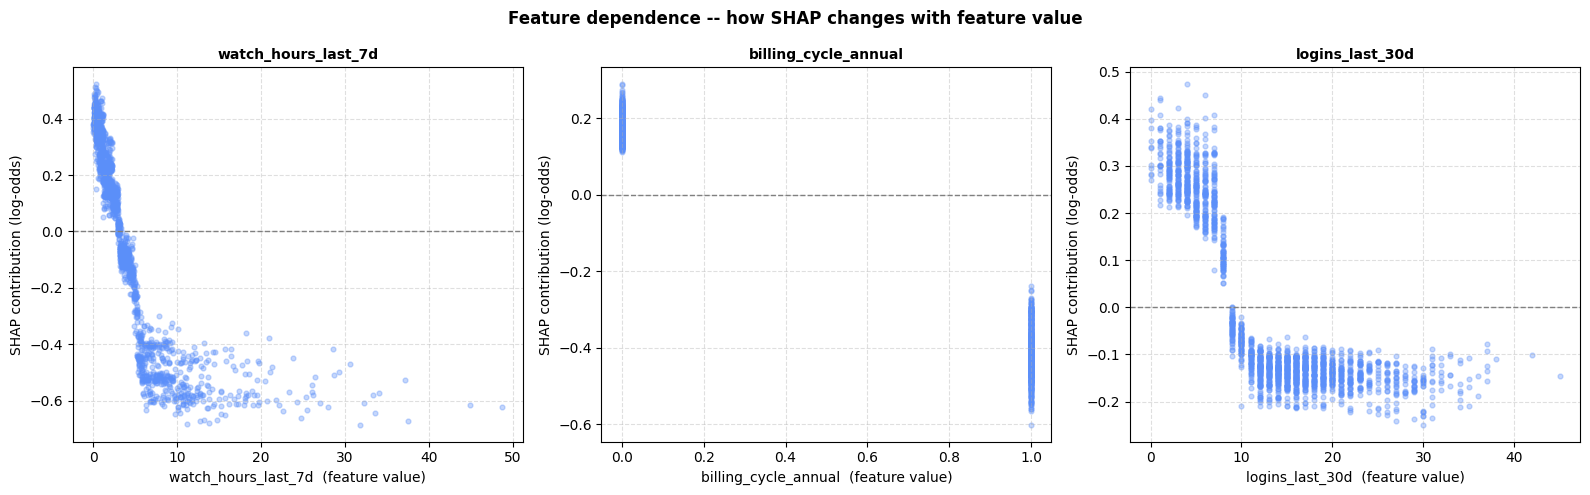

In [6]:
print("\n" + "=" * 70)
print("E. FEATURE DEPENDENCE (top 3 drivers)")
print("=" * 70)
top_3 = importance["feature"].head(3).tolist()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat in zip(axes, top_3):
    idx = list(X_shap.columns).index(feat)
    x = X_shap.iloc[:, idx].values
    s = shap_values.values[:, idx]
    ax.scatter(x, s, alpha=0.35, s=12, color="#5B8FF9")
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel(f"{feat}  (feature value)")
    ax.set_ylabel("SHAP contribution (log-odds)")
    ax.set_title(feat, fontweight="bold", fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Feature dependence -- how SHAP changes with feature value",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_shap_dependence.png", dpi=140, bbox_inches="tight")
print(f"Saved -> {FIG_DIR}/05_shap_dependence.png")
print(f"\nTop 3 drivers:")
for feat in top_3:
    print(f"  - {feat}")

## F. Local explanations — three worked examples

Pick one user at each risk tier (highest, marginal, lowest) and walk through the top
SHAP contributions. Attach the recommended intervention for the top `RISK+` feature.
This is the pattern the Streamlit app uses in the Per-user lookup tab.

In [7]:
print("\n" + "=" * 70)
print("F. LOCAL EXPLANATIONS -- three worked examples")
print("=" * 70)

pred_proba = hgb.predict_proba(X_shap)[:, 1]

# "Marginal" = closest to the Phase 6 EV decision boundary, not an arbitrary
# probability like 0.15. Per-user break-even P* for each lever is
#     P*(churn) = cost / (uplift × LTV_user)
# A user becomes targetable when their P(churn) exceeds the CHEAPEST lever's
# P* (i.e., the min across levers -- first EV to cross zero). The marginal
# example is whoever sits closest to that personal boundary.
user_ltv = df.loc[X_shap.index, "plan_tier"].map(LTV_BY_TIER).values
per_lever_boundaries = np.array([
    params["cost"] / (params["uplift"] * user_ltv)
    for params in INTERVENTION_MENU.values()
])                                              # shape: (n_levers, n_users)
per_user_min_boundary = per_lever_boundaries.min(axis=0)
marginal_idx = int(np.argmin(np.abs(pred_proba - per_user_min_boundary)))

# Pick three example indices at different risk levels
# 1. Highest-risk user (model most confident of churn)
# 2. Marginal case at the user's personal EV break-even
# 3. Confidently retained user (control example)
example_indices = [
    ("HIGH RISK   ", int(np.argmax(pred_proba))),
    ("MARGINAL    ", marginal_idx),
    ("LOW RISK    ", int(np.argmin(pred_proba))),
]
print(f"Marginal user's EV break-even (cheapest lever): "
      f"P*={per_user_min_boundary[marginal_idx]:.3f}  |  "
      f"actual P(churn)={pred_proba[marginal_idx]:.3f}")

FEAT_W, VAL_W, SHAP_W = 32, 8, 7   # column widths for the compact table
for label, idx in example_indices:
    p = pred_proba[idx]
    actual = int(y_shap.iloc[idx])
    print(f"\n[{label.strip()}]  P(churn)={p:.3f}  actual={actual}")
    local = local_explanation(shap_values, X_shap, list(X_shap.columns),
                              idx=idx, top_n=5)
    # Compact fixed-width table -- avoids pandas' auto-truncation in Jupyter
    print(f"  {'feature':<{FEAT_W}} {'value':>{VAL_W}} {'shap':>{SHAP_W}}  dir")
    print(f"  {'-' * FEAT_W} {'-' * VAL_W} {'-' * SHAP_W}  ----")
    for _, r in local.iterrows():
        feat = str(r["feature"])[:FEAT_W]
        print(f"  {feat:<{FEAT_W}} "
              f"{float(r['feature_value']):>{VAL_W}.2f} "
              f"{r['shap_value']:>+{SHAP_W}.3f}  {r['direction']}")

    top_risk = local[local["direction"] == "RISK+"].head(1)
    if not top_risk.empty:
        feat = top_risk["feature"].iloc[0]
        lever = map_to_intervention(feat)
        print(f"  -> Lever: {lever['lever']} "
              f"(cost=${lever['cost']:.0f}) -- {lever['note']}")


F. LOCAL EXPLANATIONS -- three worked examples
Marginal user's EV break-even (cheapest lever): P*=0.046  |  actual P(churn)=0.046

[HIGH RISK]  P(churn)=0.421  actual=1
  feature                             value    shap  dir
  -------------------------------- -------- -------  ----
  payment_health_score                 2.00  +0.783  RISK+
  watch_hours_last_7d                  0.08  +0.407  RISK+
  logins_last_30d                      4.00  +0.392  RISK+
  billing_cycle_annual                 0.00  +0.287  RISK+
  watch_trend_30d_to_90d               0.75  +0.211  RISK+
  -> Lever: Payment method update prompt + $5 credit (cost=$5) -- Composite payment risk score

[MARGINAL]  P(churn)=0.046  actual=0
  feature                             value    shap  dir
  -------------------------------- -------- -------  ----
  watch_hours_last_7d                  2.03  +0.230  RISK+
  billing_cycle_annual                 0.00  +0.162  RISK+
  watch_trend_30d_to_90d               0.84  +0.129  R

## G. Feature → intervention mapping table

The bridge between model and decision rule. Every flagged feature has a paired lever
(or "no lever" if the feature is diagnostic-only). This mapping was curated with the
PM and lives in `src/models/explain.py:FEATURE_INTERVENTION_MAP`.

In [8]:
print("\n" + "=" * 70)
print("G. FEATURE -> INTERVENTION MAPPING")
print("=" * 70)
lever_rows = []
for feat, spec in FEATURE_INTERVENTION_MAP.items():
    lever_rows.append({
        "feature": feat,
        "lever": spec["lever"],
        "cost": spec["cost"],
        "note": spec["note"],
    })
lever_df = pd.DataFrame(lever_rows)
print(lever_df.to_string(index=False))


G. FEATURE -> INTERVENTION MAPPING
                       feature                                    lever  cost                                                                   note
         watch_trend_7d_to_30d                Personalized content push   1.0             Declining engagement -> curated playlist push notification
        watch_trend_30d_to_90d                Personalized content push   1.0        Slow-burn disengagement -> re-engagement email + trailer bundle
         days_since_last_login             Re-engagement email sequence   1.0                              Inactive users need a reason to come back
               logins_last_30d             Re-engagement email sequence   1.0                             Low login frequency -> weekly recap emails
            support_tickets_7d             White-glove support callback   5.0                 Recent ticket escalation -> proactive support outreach
         tickets_recency_ratio             White-glove support callbac

## H. Verdict + handoff to Phase 6

Roll up the top drivers, count how many have actionable levers, and describe what
Phase 6 will consume: per-user P(churn), top SHAP driver, lever cost, lever uplift,
LTV by tier.

In [9]:
print("\n" + "=" * 70)
print("H. PHASE 5 VERDICT")
print("=" * 70)
top_5 = importance.head(5)["feature"].tolist()
print(f"\nTop 5 SHAP drivers overall:")
for feat in top_5:
    lever = map_to_intervention(feat)
    print(f"  - {feat:<35}  lever: {lever['lever']}")
print(
    f"\nOf the top 15 features, "
    f"{sum(1 for f in importance['feature'] if map_to_intervention(f)['cost'] > 0)}"
    f" have an actionable intervention lever."
)
print("\nHandoff to Phase 6 (cost-aware decision rule):")
print("  - Per-user P(churn) from the calibrated HistGBM")
print("  - Per-user top SHAP driver from this notebook")
print("  - Intervention cost + expected uplift from the lever mapping above")
print("  - LTV by plan tier from the scenario brief")
print("\nDecision rule = argmax over levers of (P(churn) x uplift x LTV - cost).")


H. PHASE 5 VERDICT

Top 5 SHAP drivers overall:
  - watch_hours_last_7d                  lever: Re-engagement email sequence
  - billing_cycle_annual                 lever: Upgrade-to-annual offer
  - logins_last_30d                      lever: Re-engagement email sequence
  - days_since_last_login                lever: Re-engagement email sequence
  - payment_health_score                 lever: Payment method update prompt + $5 credit

Of the top 15 features, 8 have an actionable intervention lever.

Handoff to Phase 6 (cost-aware decision rule):
  - Per-user P(churn) from the calibrated HistGBM
  - Per-user top SHAP driver from this notebook
  - Intervention cost + expected uplift from the lever mapping above
  - LTV by plan tier from the scenario brief

Decision rule = argmax over levers of (P(churn) x uplift x LTV - cost).
